# Step 2: Sequence Alignment & Preprocessing
## Comparative Lassa-Ebola Mutation Study

**What we're doing:**
1. Load cleaned sequences from previous step
2. Remove stop codons (*) and invalid characters
3. Perform sequence alignment (MSA)
4. Extract sequence features
5. Prepare for ESM embeddings

## Section 1: Setup & Install Dependencies

In [1]:
# Install required packages
!pip install biopython pandas numpy matplotlib seaborn scikit-learn -q

import pandas as pd
import numpy as np
from Bio import SeqIO, Align, AlignIO
from Bio.SeqUtils.ProtParam import ProteinAnalysis
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
from pathlib import Path

print("✅ All dependencies installed successfully")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 32.6 MB/s eta 0:00:00
✅ All dependencies installed successfully


## Section 2: Download Raw FASTA Files from GitHub

In [15]:
import urllib.request
import os

# Create directories
os.makedirs('data/raw', exist_ok=True)
os.makedirs('data/processed', exist_ok=True)

# GitHub raw content URLs
repo_owner = "Damilola-max"
repo_name = "Comparative_Lassa_Ebola-Model"
branch = "main"

lassa_url = f"https://raw.githubusercontent.com/{repo_owner}/{repo_name}/{branch}/data/raw/S_protein.fas"
ebola_url = f"https://raw.githubusercontent.com/{repo_owner}/{repo_name}/{branch}/data/raw/Ebola_Protein_Sequence.fas"

# Download files
print("📥 Downloading Lassa S protein sequences...")
urllib.request.urlretrieve(lassa_url, "data/raw/S_protein.fas")
print("✅ Lassa S protein downloaded")

print("\n📥 Downloading Ebola sequences...")
urllib.request.urlretrieve(ebola_url, "data/raw/Ebola_Protein_Sequence.fas")
print("✅ Ebola sequences downloaded")

# Verify
print("\n📁 Files downloaded:")
for f in os.listdir('data/raw'):
    size = os.path.getsize(f'data/raw/{f}') / (1024*1024)  # MB
    print(f"  - {f}: {size:.2f} MB")

📥 Downloading Lassa S protein sequences...
✅ Lassa S protein downloaded

📥 Downloading Ebola sequences...
✅ Ebola sequences downloaded

📁 Files downloaded:
  - S_protein.fas: 0.85 MB
  - Ebola_Protein_Sequence.fas: 9.80 MB


## Section 3: Clean Sequences - Remove Invalid Characters

In [16]:
from Bio.Seq import Seq

def clean_sequence(seq_str):
    """
    Remove stop codons and invalid characters from protein sequence
    """
    # Remove stop codons, gaps, and unknown amino acids 'X'
    cleaned = seq_str.replace('*', '').replace('-', '').replace('?', '').replace('X', '')
    return cleaned.upper()

def parse_and_clean_fasta(input_file, output_file, virus_type):
    """
    Parse FASTA file, clean sequences, and save cleaned version
    """
    cleaned_records = []
    skipped = 0

    print(f"\n🔄 Processing {virus_type} sequences...")

    for record in SeqIO.parse(input_file, "fasta"):
        seq_str = str(record.seq)

        # Skip if too short
        if len(seq_str) < 50:
            skipped += 1
            continue

        # Clean sequence
        cleaned_seq = clean_sequence(seq_str)

        if len(cleaned_seq) > 0:  # Only keep if not empty after cleaning
            record.seq = Seq(cleaned_seq)  # Convert string to Seq object
            cleaned_records.append(record)
        else:
            skipped += 1

    # Save cleaned FASTA
    SeqIO.write(cleaned_records, output_file, "fasta")

    print(f"✅ Cleaned {len(cleaned_records)} {virus_type} sequences")
    print(f"⚠️  Skipped {skipped} short/invalid sequences")
    print(f"📄 Saved to: {output_file}")

    return cleaned_records

# Clean both datasets
lassa_records = parse_and_clean_fasta(
    'data/raw/S_protein.fas',
    'data/processed/lassa_cleaned.fasta',
    'Lassa'
)

ebola_records = parse_and_clean_fasta(
    'data/raw/Ebola_Protein_Sequence.fas',
    'data/processed/ebola_cleaned.fasta',
    'Ebola'
)

print(f"\n📊 Summary:")
print(f"  Lassa sequences: {len(lassa_records)}")
print(f"  Ebola sequences: {len(ebola_records)}")
print(f"  Total: {len(lassa_records) + len(ebola_records)}")


🔄 Processing Lassa sequences...
✅ Cleaned 780 Lassa sequences
⚠️  Skipped 0 short/invalid sequences
📄 Saved to: data/processed/lassa_cleaned.fasta

🔄 Processing Ebola sequences...
✅ Cleaned 1610 Ebola sequences
⚠️  Skipped 0 short/invalid sequences
📄 Saved to: data/processed/ebola_cleaned.fasta

📊 Summary:
  Lassa sequences: 780
  Ebola sequences: 1610
  Total: 2390


## Section 4: Extract Sequence Statistics & Metadata

In [17]:
def extract_sequence_features(records, virus_name):
    """
    Extract biochemical features from protein sequences

    Features extracted:
    - Sequence ID
    - Length
    - Molecular Weight
    - Isoelectric Point (pI)
    - Aromaticity
    - Instability Index
    - GRAVY (Grand Average of Hydropathy)
    """

    features_list = []

    for record in records:
        seq = str(record.seq)

        try:
            # Use BioPython's ProteinAnalysis
            analysis = ProteinAnalysis(seq)

            features = {
                'sequence_id': record.id,
                'virus': virus_name,
                'length': len(seq),
                'molecular_weight': analysis.molecular_weight(),
                'isoelectric_point': analysis.isoelectric_point(),
                'aromaticity': analysis.aromaticity(),
                'instability_index': analysis.instability_index(),
                'gravy': analysis.gravy(),
            }
            features_list.append(features)
        except Exception as e:
            print(f"⚠️  Error processing {record.id}: {str(e)}")
            continue

    return pd.DataFrame(features_list)

print("🔬 Extracting biochemical features...\n")

lassa_df = extract_sequence_features(lassa_records, 'Lassa')
ebola_df = extract_sequence_features(ebola_records, 'Ebola')

# Combine
metadata_df = pd.concat([lassa_df, ebola_df], ignore_index=True)

# Save metadata
metadata_df.to_csv('data/processed/sequence_metadata.csv', index=False)
print(f"✅ Metadata saved: sequence_metadata.csv")

# Display statistics
print(f"\n📊 Sequence Statistics:\n")
print(metadata_df.groupby('virus')[['length', 'molecular_weight', 'isoelectric_point']].describe().round(2))

🔬 Extracting biochemical features...

✅ Metadata saved: sequence_metadata.csv

📊 Sequence Statistics:

       length                                                           \
        count     mean     std     min     25%     50%     75%     max   
virus                                                                    
Ebola  1610.0  5869.03  203.18  2820.0  5891.0  5928.0  5941.0  5960.0   
Lassa   780.0  1057.19   54.84   664.0  1049.0  1066.0  1088.0  1160.0   

      molecular_weight             ...                        \
                 count       mean  ...        75%        max   
virus                              ...                         
Ebola           1610.0  673635.42  ...  681894.03  684190.47   
Lassa            780.0  118798.11  ...  122390.51  130412.91   

      isoelectric_point                                            
                  count  mean   std   min   25%   50%   75%   max  
virus                                                              
E

## Section 5: Visualize Sequence Properties

✅ Visualization saved: results/figures/01_sequence_properties.png


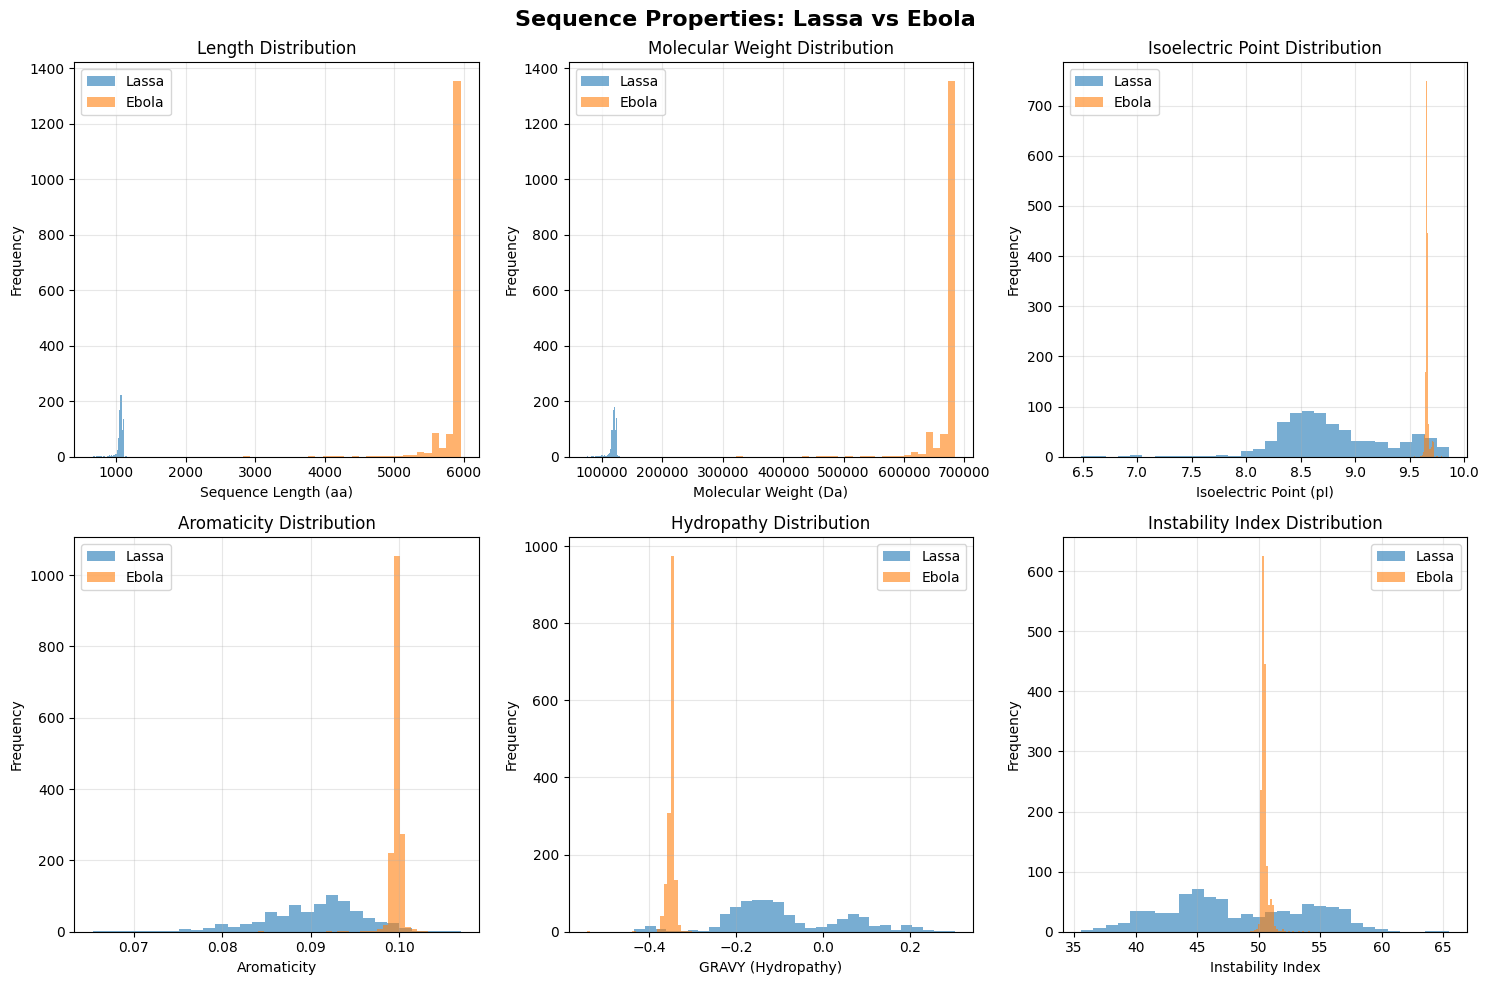

In [18]:
# Create visualizations
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Sequence Properties: Lassa vs Ebola', fontsize=16, fontweight='bold')

# Sequence Length
ax = axes[0, 0]
for virus in ['Lassa', 'Ebola']:
    data = metadata_df[metadata_df['virus'] == virus]['length']
    ax.hist(data, bins=30, alpha=0.6, label=virus)
ax.set_xlabel('Sequence Length (aa)')
ax.set_ylabel('Frequency')
ax.set_title('Length Distribution')
ax.legend()
ax.grid(alpha=0.3)

# Molecular Weight
ax = axes[0, 1]
for virus in ['Lassa', 'Ebola']:
    data = metadata_df[metadata_df['virus'] == virus]['molecular_weight']
    ax.hist(data, bins=30, alpha=0.6, label=virus)
ax.set_xlabel('Molecular Weight (Da)')
ax.set_ylabel('Frequency')
ax.set_title('Molecular Weight Distribution')
ax.legend()
ax.grid(alpha=0.3)

# Isoelectric Point
ax = axes[0, 2]
for virus in ['Lassa', 'Ebola']:
    data = metadata_df[metadata_df['virus'] == virus]['isoelectric_point']
    ax.hist(data, bins=30, alpha=0.6, label=virus)
ax.set_xlabel('Isoelectric Point (pI)')
ax.set_ylabel('Frequency')
ax.set_title('Isoelectric Point Distribution')
ax.legend()
ax.grid(alpha=0.3)

# Aromaticity
ax = axes[1, 0]
for virus in ['Lassa', 'Ebola']:
    data = metadata_df[metadata_df['virus'] == virus]['aromaticity']
    ax.hist(data, bins=30, alpha=0.6, label=virus)
ax.set_xlabel('Aromaticity')
ax.set_ylabel('Frequency')
ax.set_title('Aromaticity Distribution')
ax.legend()
ax.grid(alpha=0.3)

# GRAVY (Hydropathy)
ax = axes[1, 1]
for virus in ['Lassa', 'Ebola']:
    data = metadata_df[metadata_df['virus'] == virus]['gravy']
    ax.hist(data, bins=30, alpha=0.6, label=virus)
ax.set_xlabel('GRAVY (Hydropathy)')
ax.set_ylabel('Frequency')
ax.set_title('Hydropathy Distribution')
ax.legend()
ax.grid(alpha=0.3)

# Instability Index
ax = axes[1, 2]
for virus in ['Lassa', 'Ebola']:
    data = metadata_df[metadata_df['virus'] == virus]['instability_index']
    ax.hist(data, bins=30, alpha=0.6, label=virus)
ax.set_xlabel('Instability Index')
ax.set_ylabel('Frequency')
ax.set_title('Instability Index Distribution')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
os.makedirs('results/figures', exist_ok=True) # Create directory if it doesn't exist
plt.savefig('results/figures/01_sequence_properties.png', dpi=300, bbox_inches='tight')
print("✅ Visualization saved: results/figures/01_sequence_properties.png")
plt.show()

## Section 6: Select Representative Sequences for Alignment

**Why:**
- Multiple sequence alignment (MSA) of 1000+ sequences is computationally expensive
- We'll select representative sequences while keeping diversity
- Full set can be used in embeddings later

In [19]:
def select_diverse_sequences(records, n_select=20, seed=42):
    """
    Select diverse sequences based on length distribution
    """
    np.random.seed(seed)

    # Stratified sampling by length
    records_df = pd.DataFrame([
        {'record': r, 'length': len(str(r.seq))}
        for r in records
    ])

    # Create length bins
    records_df['length_bin'] = pd.cut(records_df['length'], bins=5)

    # Sample from each bin
    selected = []
    for bin_val in records_df['length_bin'].unique():
        bin_records = records_df[records_df['length_bin'] == bin_val]
        n_in_bin = max(1, len(bin_records) // len(records_df['length_bin'].unique()))
        selected.extend(bin_records.sample(min(n_in_bin, len(bin_records)))['record'].tolist())

    return selected[:n_select]

# Select representatives
lassa_representatives = select_diverse_sequences(lassa_records, n_select=10)
ebola_representatives = select_diverse_sequences(ebola_records, n_select=10)

print(f"✅ Selected {len(lassa_representatives)} diverse Lassa sequences")
print(f"✅ Selected {len(ebola_representatives)} diverse Ebola sequences")

# Save representatives
all_representatives = lassa_representatives + ebola_representatives
SeqIO.write(all_representatives, 'data/processed/representative_sequences.fasta', 'fasta')
print(f"\n✅ Saved to: data/processed/representative_sequences.fasta")

✅ Selected 10 diverse Lassa sequences
✅ Selected 10 diverse Ebola sequences

✅ Saved to: data/processed/representative_sequences.fasta


## Section 7: Create Comprehensive Dataset Summary

In [20]:
# Create summary statistics
summary = {
    'total_sequences': len(metadata_df),
    'lassa_count': len(lassa_df),
    'ebola_count': len(ebola_df),
    'lassa_avg_length': float(lassa_df['length'].mean()),
    'ebola_avg_length': float(ebola_df['length'].mean()),
    'lassa_length_std': float(lassa_df['length'].std()),
    'ebola_length_std': float(ebola_df['length'].std()),
    'representative_sequences': len(all_representatives),
    'files_created': [
        'data/processed/lassa_cleaned.fasta',
        'data/processed/ebola_cleaned.fasta',
        'data/processed/sequence_metadata.csv',
        'data/processed/representative_sequences.fasta'
    ]
}

# Save summary
with open('data/processed/preprocessing_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("\n" + "="*60)
print("📊 PREPROCESSING COMPLETE")
print("="*60)
print(f"\n📈 Dataset Summary:")
print(f"  ✅ Total sequences processed: {summary['total_sequences']}")
print(f"  ✅ Lassa sequences: {summary['lassa_count']}")
print(f"  ✅ Ebola sequences: {summary['ebola_count']}")
print(f"\n  📏 Lassa - Avg length: {summary['lassa_avg_length']:.0f} ± {summary['lassa_length_std']:.0f} aa")
print(f"  📏 Ebola - Avg length: {summary['ebola_avg_length']:.0f} ± {summary['ebola_length_std']:.0f} aa")
print(f"\n  🎯 Representative sequences selected: {summary['representative_sequences']}")
print(f"\n📁 Output files created:")
for file in summary['files_created']:
    print(f"  ✅ {file}")
print(f"  ✅ results/figures/01_sequence_properties.png")
print(f"  ✅ data/processed/preprocessing_summary.json")
print("\n" + "="*60)
print("✅ Ready for Step 3: ESM Embeddings")
print("="*60)


📊 PREPROCESSING COMPLETE

📈 Dataset Summary:
  ✅ Total sequences processed: 2390
  ✅ Lassa sequences: 780
  ✅ Ebola sequences: 1610

  📏 Lassa - Avg length: 1057 ± 55 aa
  📏 Ebola - Avg length: 5869 ± 203 aa

  🎯 Representative sequences selected: 20

📁 Output files created:
  ✅ data/processed/lassa_cleaned.fasta
  ✅ data/processed/ebola_cleaned.fasta
  ✅ data/processed/sequence_metadata.csv
  ✅ data/processed/representative_sequences.fasta
  ✅ results/figures/01_sequence_properties.png
  ✅ data/processed/preprocessing_summary.json

✅ Ready for Step 3: ESM Embeddings


In [21]:
from Bio.Seq import Seq

def clean_sequence(seq_str):
    """
    Remove stop codons and invalid characters from protein sequence
    """
    # Remove stop codons, gaps, and unknown amino acids 'X'
    cleaned = seq_str.replace('*', '').replace('-', '').replace('?', '').replace('X', '')
    return cleaned.upper()

def parse_and_clean_fasta(input_file, output_file, virus_type):
    """
    Parse FASTA file, clean sequences, and save cleaned version
    """
    cleaned_records = []
    skipped = 0

    print(f"\n🔄 Processing {virus_type} sequences...")

    for record in SeqIO.parse(input_file, "fasta"):
        seq_str = str(record.seq)

        # Skip if too short
        if len(seq_str) < 50:
            skipped += 1
            continue

        # Clean sequence
        cleaned_seq = clean_sequence(seq_str)

        if len(cleaned_seq) > 0:  # Only keep if not empty after cleaning
            record.seq = Seq(cleaned_seq)  # Convert string to Seq object
            cleaned_records.append(record)
        else:
            skipped += 1

    # Save cleaned FASTA
    SeqIO.write(cleaned_records, output_file, "fasta")

    print(f"✅ Cleaned {len(cleaned_records)} {virus_type} sequences")
    print(f"⚠️  Skipped {skipped} short/invalid sequences")
    print(f"📄 Saved to: {output_file}")

    return cleaned_records

# Clean both datasets
lassa_records = parse_and_clean_fasta(
    'data/raw/S_protein.fas',
    'data/processed/lassa_cleaned.fasta',
    'Lassa'
)

ebola_records = parse_and_clean_fasta(
    'data/raw/Ebola_Protein_Sequence.fas',
    'data/processed/ebola_cleaned.fasta',
    'Ebola'
)

print(f"\n📊 Summary:")
print(f"  Lassa sequences: {len(lassa_records)}")
print(f"  Ebola sequences: {len(ebola_records)}")
print(f"  Total: {len(lassa_records) + len(ebola_records)}")


🔄 Processing Lassa sequences...
✅ Cleaned 780 Lassa sequences
⚠️  Skipped 0 short/invalid sequences
📄 Saved to: data/processed/lassa_cleaned.fasta

🔄 Processing Ebola sequences...
✅ Cleaned 1610 Ebola sequences
⚠️  Skipped 0 short/invalid sequences
📄 Saved to: data/processed/ebola_cleaned.fasta

📊 Summary:
  Lassa sequences: 780
  Ebola sequences: 1610
  Total: 2390


In [22]:
def extract_sequence_features(records, virus_name):
    """
    Extract biochemical features from protein sequences

    Features extracted:
    - Sequence ID
    - Length
    - Molecular Weight
    - Isoelectric Point (pI)
    - Aromaticity
    - Instability Index
    - GRAVY (Grand Average of Hydropathy)
    """

    features_list = []

    for record in records:
        seq = str(record.seq)

        try:
            # Use BioPython's ProteinAnalysis
            analysis = ProteinAnalysis(seq)

            features = {
                'sequence_id': record.id,
                'virus': virus_name,
                'length': len(seq),
                'molecular_weight': analysis.molecular_weight(),
                'isoelectric_point': analysis.isoelectric_point(),
                'aromaticity': analysis.aromaticity(),
                'instability_index': analysis.instability_index(),
                'gravy': analysis.gravy(),
            }
            features_list.append(features)
        except Exception as e:
            print(f"⚠️  Error processing {record.id}: {str(e)}")
            continue

    return pd.DataFrame(features_list)

print("🔬 Extracting biochemical features...\n")

lassa_df = extract_sequence_features(lassa_records, 'Lassa')
ebola_df = extract_sequence_features(ebola_records, 'Ebola')

# Combine
metadata_df = pd.concat([lassa_df, ebola_df], ignore_index=True)

# Save metadata
metadata_df.to_csv('data/processed/sequence_metadata.csv', index=False)
print(f"✅ Metadata saved: sequence_metadata.csv")

# Display statistics
print(f"\n📊 Sequence Statistics:\n")
print(metadata_df.groupby('virus')[['length', 'molecular_weight', 'isoelectric_point']].describe().round(2))

🔬 Extracting biochemical features...

✅ Metadata saved: sequence_metadata.csv

📊 Sequence Statistics:

       length                                                           \
        count     mean     std     min     25%     50%     75%     max   
virus                                                                    
Ebola  1610.0  5869.03  203.18  2820.0  5891.0  5928.0  5941.0  5960.0   
Lassa   780.0  1057.19   54.84   664.0  1049.0  1066.0  1088.0  1160.0   

      molecular_weight             ...                        \
                 count       mean  ...        75%        max   
virus                              ...                         
Ebola           1610.0  673635.42  ...  681894.03  684190.47   
Lassa            780.0  118798.11  ...  122390.51  130412.91   

      isoelectric_point                                            
                  count  mean   std   min   25%   50%   75%   max  
virus                                                              
E

✅ Visualization saved: results/figures/01_sequence_properties.png


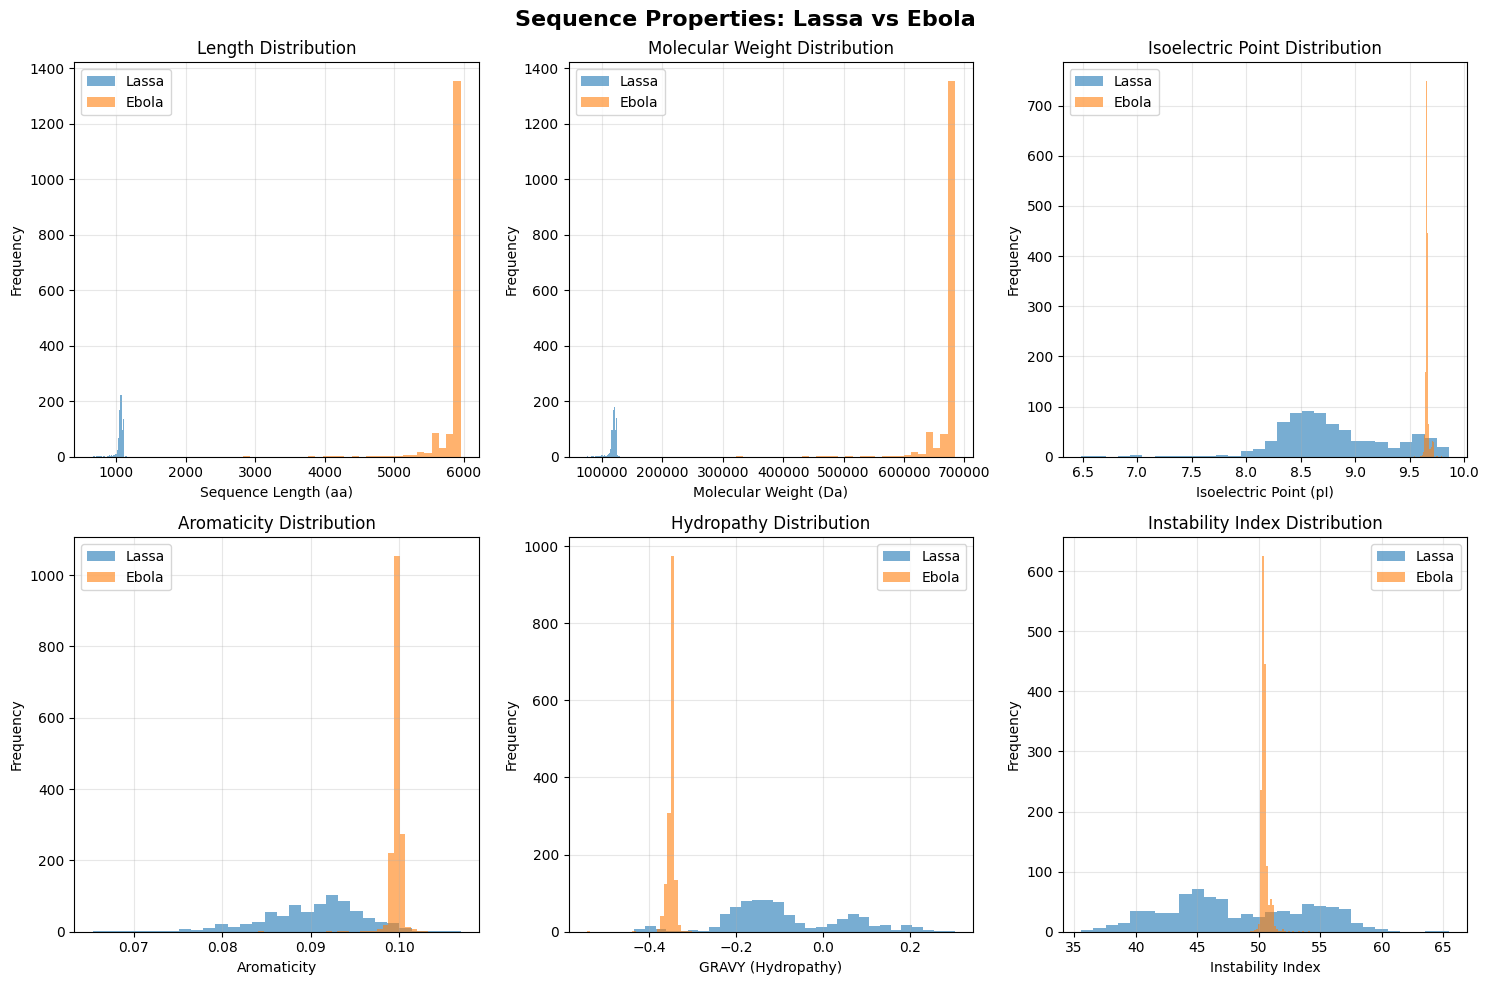

In [23]:
# Create visualizations
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Sequence Properties: Lassa vs Ebola', fontsize=16, fontweight='bold')

# Sequence Length
ax = axes[0, 0]
for virus in ['Lassa', 'Ebola']:
    data = metadata_df[metadata_df['virus'] == virus]['length']
    ax.hist(data, bins=30, alpha=0.6, label=virus)
ax.set_xlabel('Sequence Length (aa)')
ax.set_ylabel('Frequency')
ax.set_title('Length Distribution')
ax.legend()
ax.grid(alpha=0.3)

# Molecular Weight
ax = axes[0, 1]
for virus in ['Lassa', 'Ebola']:
    data = metadata_df[metadata_df['virus'] == virus]['molecular_weight']
    ax.hist(data, bins=30, alpha=0.6, label=virus)
ax.set_xlabel('Molecular Weight (Da)')
ax.set_ylabel('Frequency')
ax.set_title('Molecular Weight Distribution')
ax.legend()
ax.grid(alpha=0.3)

# Isoelectric Point
ax = axes[0, 2]
for virus in ['Lassa', 'Ebola']:
    data = metadata_df[metadata_df['virus'] == virus]['isoelectric_point']
    ax.hist(data, bins=30, alpha=0.6, label=virus)
ax.set_xlabel('Isoelectric Point (pI)')
ax.set_ylabel('Frequency')
ax.set_title('Isoelectric Point Distribution')
ax.legend()
ax.grid(alpha=0.3)

# Aromaticity
ax = axes[1, 0]
for virus in ['Lassa', 'Ebola']:
    data = metadata_df[metadata_df['virus'] == virus]['aromaticity']
    ax.hist(data, bins=30, alpha=0.6, label=virus)
ax.set_xlabel('Aromaticity')
ax.set_ylabel('Frequency')
ax.set_title('Aromaticity Distribution')
ax.legend()
ax.grid(alpha=0.3)

# GRAVY (Hydropathy)
ax = axes[1, 1]
for virus in ['Lassa', 'Ebola']:
    data = metadata_df[metadata_df['virus'] == virus]['gravy']
    ax.hist(data, bins=30, alpha=0.6, label=virus)
ax.set_xlabel('GRAVY (Hydropathy)')
ax.set_ylabel('Frequency')
ax.set_title('Hydropathy Distribution')
ax.legend()
ax.grid(alpha=0.3)

# Instability Index
ax = axes[1, 2]
for virus in ['Lassa', 'Ebola']:
    data = metadata_df[metadata_df['virus'] == virus]['instability_index']
    ax.hist(data, bins=30, alpha=0.6, label=virus)
ax.set_xlabel('Instability Index')
ax.set_ylabel('Frequency')
ax.set_title('Instability Index Distribution')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
os.makedirs('results/figures', exist_ok=True) # Create directory if it doesn't exist
plt.savefig('results/figures/01_sequence_properties.png', dpi=300, bbox_inches='tight')
print("✅ Visualization saved: results/figures/01_sequence_properties.png")
plt.show()

In [24]:
def select_diverse_sequences(records, n_select=20, seed=42):
    """
    Select diverse sequences based on length distribution
    """
    np.random.seed(seed)

    # Stratified sampling by length
    records_df = pd.DataFrame([
        {'record': r, 'length': len(str(r.seq))}
        for r in records
    ])

    # Create length bins
    records_df['length_bin'] = pd.cut(records_df['length'], bins=5)

    # Sample from each bin
    selected = []
    for bin_val in records_df['length_bin'].unique():
        bin_records = records_df[records_df['length_bin'] == bin_val]
        n_in_bin = max(1, len(bin_records) // len(records_df['length_bin'].unique()))
        selected.extend(bin_records.sample(min(n_in_bin, len(bin_records)))['record'].tolist())

    return selected[:n_select]

# Select representatives
lassa_representatives = select_diverse_sequences(lassa_records, n_select=10)
ebola_representatives = select_diverse_sequences(ebola_records, n_select=10)

print(f"✅ Selected {len(lassa_representatives)} diverse Lassa sequences")
print(f"✅ Selected {len(ebola_representatives)} diverse Ebola sequences")

# Save representatives
all_representatives = lassa_representatives + ebola_representatives
SeqIO.write(all_representatives, 'data/processed/representative_sequences.fasta', 'fasta')
print(f"\n✅ Saved to: data/processed/representative_sequences.fasta")

✅ Selected 10 diverse Lassa sequences
✅ Selected 10 diverse Ebola sequences

✅ Saved to: data/processed/representative_sequences.fasta


In [25]:
# Create summary statistics
summary = {
    'total_sequences': len(metadata_df),
    'lassa_count': len(lassa_df),
    'ebola_count': len(ebola_df),
    'lassa_avg_length': float(lassa_df['length'].mean()),
    'ebola_avg_length': float(ebola_df['length'].mean()),
    'lassa_length_std': float(lassa_df['length'].std()),
    'ebola_length_std': float(ebola_df['length'].std()),
    'representative_sequences': len(all_representatives),
    'files_created': [
        'data/processed/lassa_cleaned.fasta',
        'data/processed/ebola_cleaned.fasta',
        'data/processed/sequence_metadata.csv',
        'data/processed/representative_sequences.fasta'
    ]
}

# Save summary
with open('data/processed/preprocessing_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("\n" + "="*60)
print("📊 PREPROCESSING COMPLETE")
print("="*60)
print(f"\n📈 Dataset Summary:")
print(f"  ✅ Total sequences processed: {summary['total_sequences']}")
print(f"  ✅ Lassa sequences: {summary['lassa_count']}")
print(f"  ✅ Ebola sequences: {summary['ebola_count']}")
print(f"\n  📏 Lassa - Avg length: {summary['lassa_avg_length']:.0f} ± {summary['lassa_length_std']:.0f} aa")
print(f"  📏 Ebola - Avg length: {summary['ebola_avg_length']:.0f} ± {summary['ebola_length_std']:.0f} aa")
print(f"\n  🎯 Representative sequences selected: {summary['representative_sequences']}")
print(f"\n📁 Output files created:")
for file in summary['files_created']:
    print(f"  ✅ {file}")
print(f"  ✅ results/figures/01_sequence_properties.png")
print(f"  ✅ data/processed/preprocessing_summary.json")
print("\n" + "="*60)
print("✅ Ready for Step 3: ESM Embeddings")
print("="*60)


📊 PREPROCESSING COMPLETE

📈 Dataset Summary:
  ✅ Total sequences processed: 2390
  ✅ Lassa sequences: 780
  ✅ Ebola sequences: 1610

  📏 Lassa - Avg length: 1057 ± 55 aa
  📏 Ebola - Avg length: 5869 ± 203 aa

  🎯 Representative sequences selected: 20

📁 Output files created:
  ✅ data/processed/lassa_cleaned.fasta
  ✅ data/processed/ebola_cleaned.fasta
  ✅ data/processed/sequence_metadata.csv
  ✅ data/processed/representative_sequences.fasta
  ✅ results/figures/01_sequence_properties.png
  ✅ data/processed/preprocessing_summary.json

✅ Ready for Step 3: ESM Embeddings


## Next Steps

✅ **Completed:**
- Cleaned sequences (removed stop codons, invalid characters)
- Extracted biochemical features
- Created visualizations
- Selected representative sequences

📋 **What's Next (Step 3):**
- Load cleaned sequences
- Generate ESM embeddings using Facebook's ESM model
- Save embeddings for mutation analysis
- Prepare data for machine learning

💡 **Key Points:**
- ESM model requires ~7-8 GB GPU memory
- We'll use ESM-1b (1.3B parameters) for efficiency
- Embeddings capture evolutionary and structural information
- These will be used to predict harmful vs. harmless mutations